In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
import scipy.cluster.hierarchy as sc
from sklearn.cluster import AgglomerativeClustering
from sklearn.datasets import make_moons
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
import collections
from mlxtend.preprocessing.transactionencoder import TransactionEncoder
from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import fpgrowth

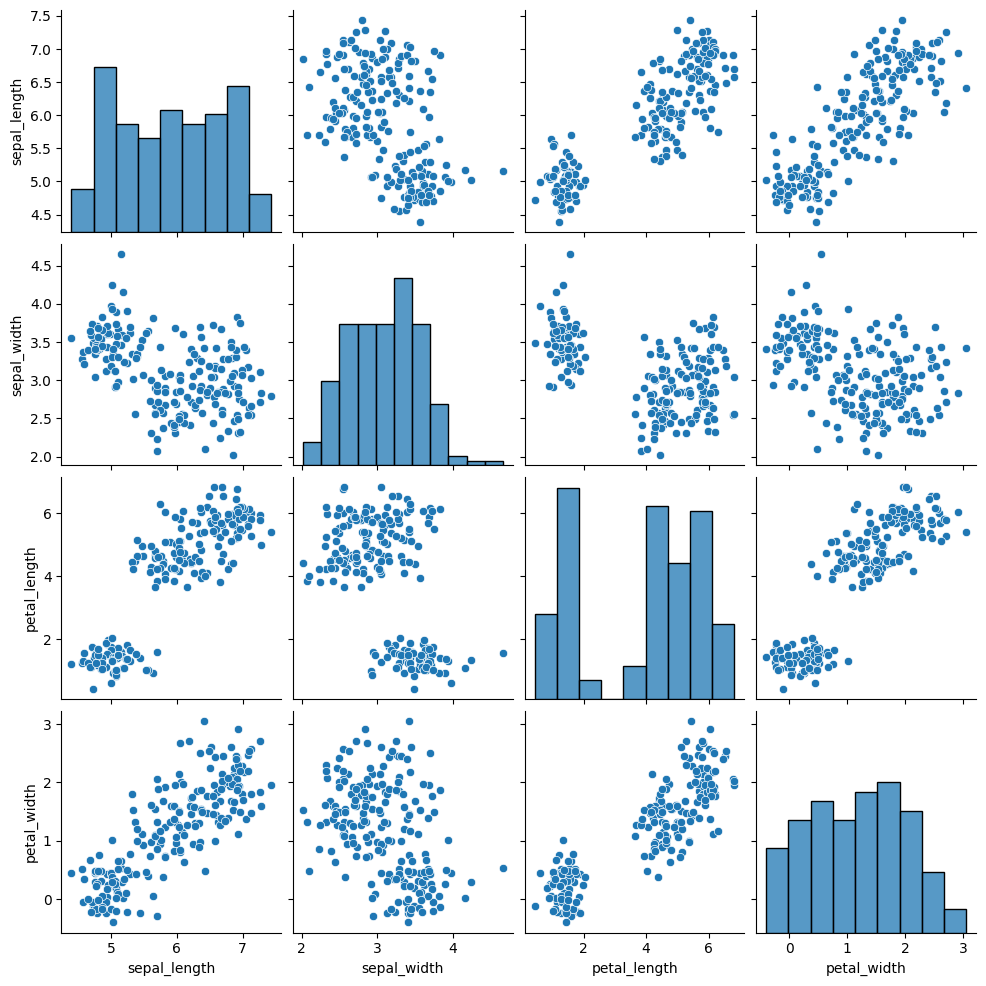

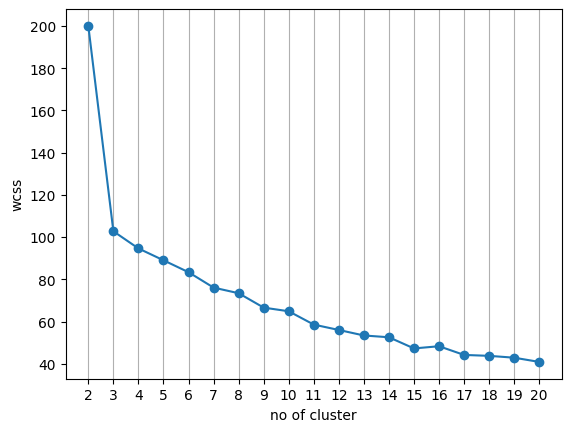

     sepal_length  sepal_width  petal_length  petal_width  predict
0        6.824299     3.502136      4.400414     1.688628        2
1        5.154514     4.655819      1.571267     0.540670        1
2        6.908632     2.489301      5.367577     2.421261        0
3        7.134277     2.548117      6.011922     2.576627        0
4        5.362229     2.560250      4.502097     1.318792        2
..            ...          ...           ...          ...      ...
195      4.796923     3.683503      1.709300     0.479384        1
196      5.243758     3.906872      1.378397     0.501060        1
197      6.048118     3.005776      4.784646     0.850143        2
198      7.007064     2.709702      5.874707     1.697847        0
199      6.935399     2.833885      6.053113     2.908277        0

[200 rows x 5 columns]
[2 1 0 0 2 2 2 1 0 2 1 1 2 1 1 1 1 2 1 2 2 2 1 2 1 0 1 1 2 1 2 2 0 1 2 1 2
 0 2 2 0 0 1 1 2 1 2 2 1 2 0 1 0 1 2 2 0 2 0 2 1 2 1 2 2 1 0 0 1 0 1 2 2 0
 2 1 2 1 2 1 0 0 0 1 1

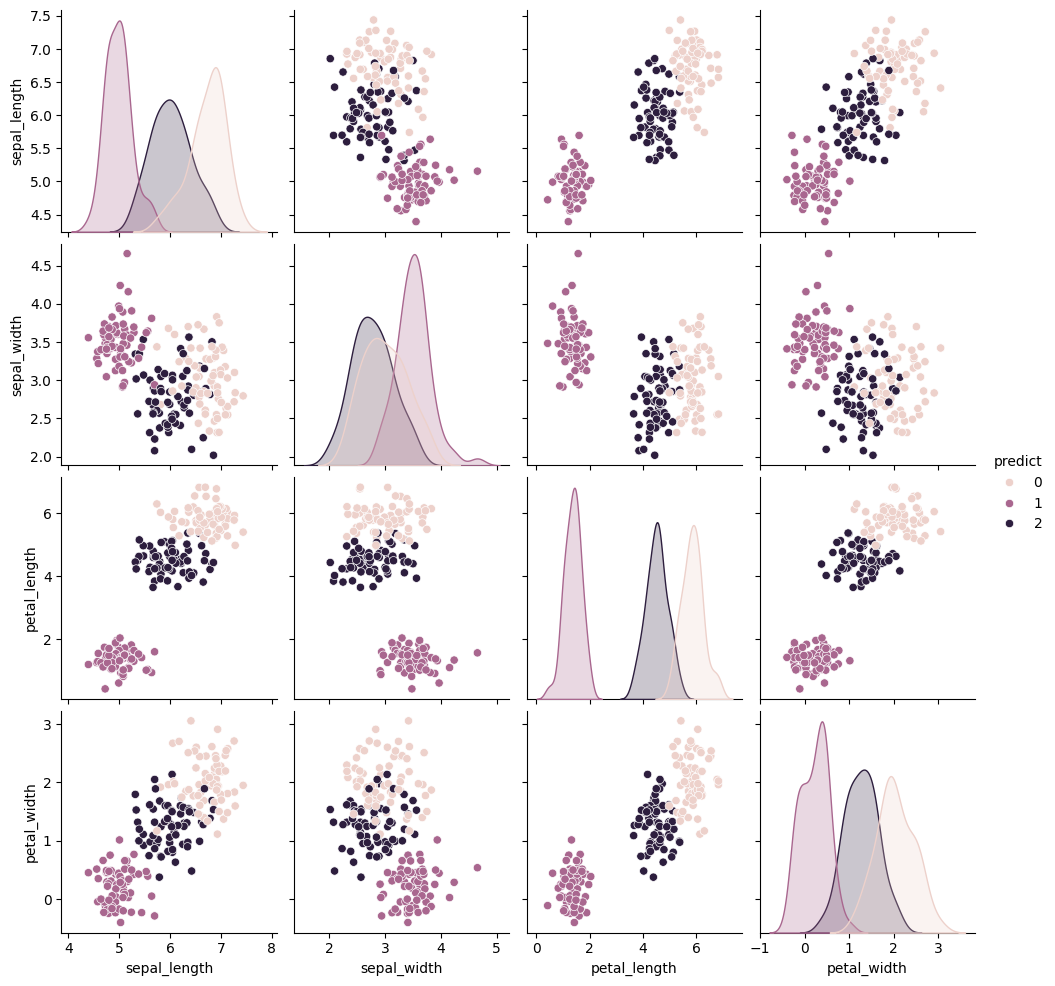

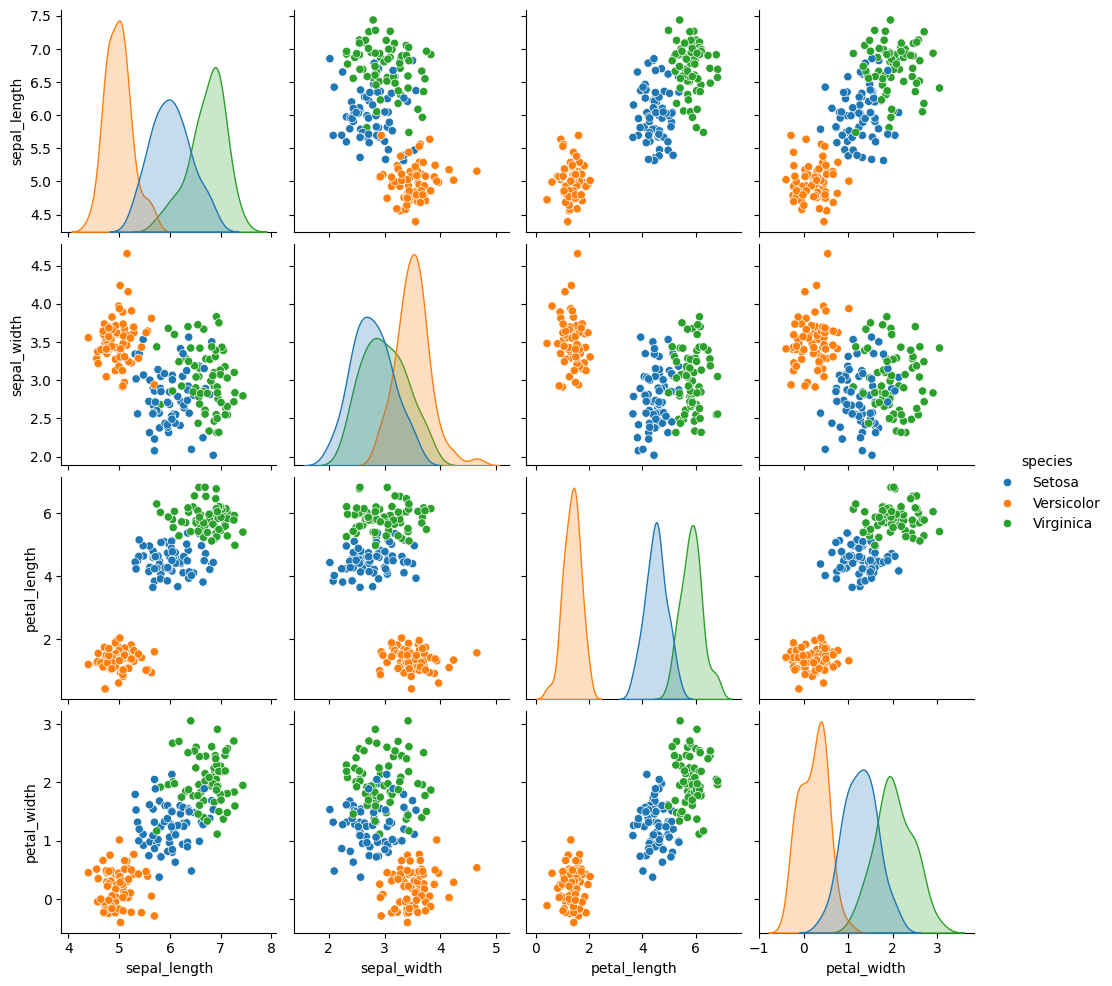

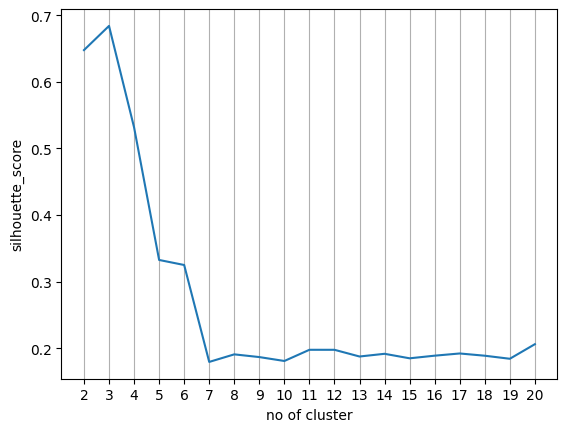

In [2]:
dataset = pd.read_csv("../datasets/iris_data.csv")
dataset.columns = dataset.columns.str.strip()
dataset.head()
dataset.isnull().sum()
sns.pairplot(data=dataset)
plt.show()
wcss = []

for i in range(2,21):
    km = KMeans(n_clusters = i, init='k-means++')
    km.fit(dataset)
    wcss.append(km.inertia_)
plt.Figure(figsize=(10,5))
plt.plot([i for i in range(2,21)],wcss,marker="o")
plt.xlabel("no of cluster")
plt.xticks([i for i in range(2,21)])
plt.ylabel("wcss")
plt.grid(axis="x")
plt.show()

kmn = KMeans(n_clusters=3)
dataset["predict"] = kmn.fit_predict(dataset)
print(dataset)
print(kmn.labels_)
print(silhouette_score(dataset,labels=kmn.labels_))
sns.pairplot(data=dataset,hue="predict")
plt.show()
org_dataset = pd.read_csv("../datasets/iris_data_species.csv")
sns.pairplot(data=org_dataset,hue="species")
plt.show()
ss = []
no_c = [j for j in range(2,21)]
for i in range(2,21):
    km1 = KMeans(n_clusters=i)
    km1.fit(dataset)
    ss.append(silhouette_score(dataset,km1.labels_))
plt.plot(no_c,ss)
plt.xlabel("no of cluster")
plt.ylabel("silhouette_score")
plt.xticks(no_c)
plt.grid(axis="x")
plt.show()

   sepal_length  sepal_width  petal_length  petal_width
0      6.824299     3.502136      4.400414     1.688628
1      5.154514     4.655819      1.571267     0.540670
2      6.908632     2.489301      5.367577     2.421261
3      7.134277     2.548117      6.011922     2.576627
4      5.362229     2.560250      4.502097     1.318792
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
dtype: int64


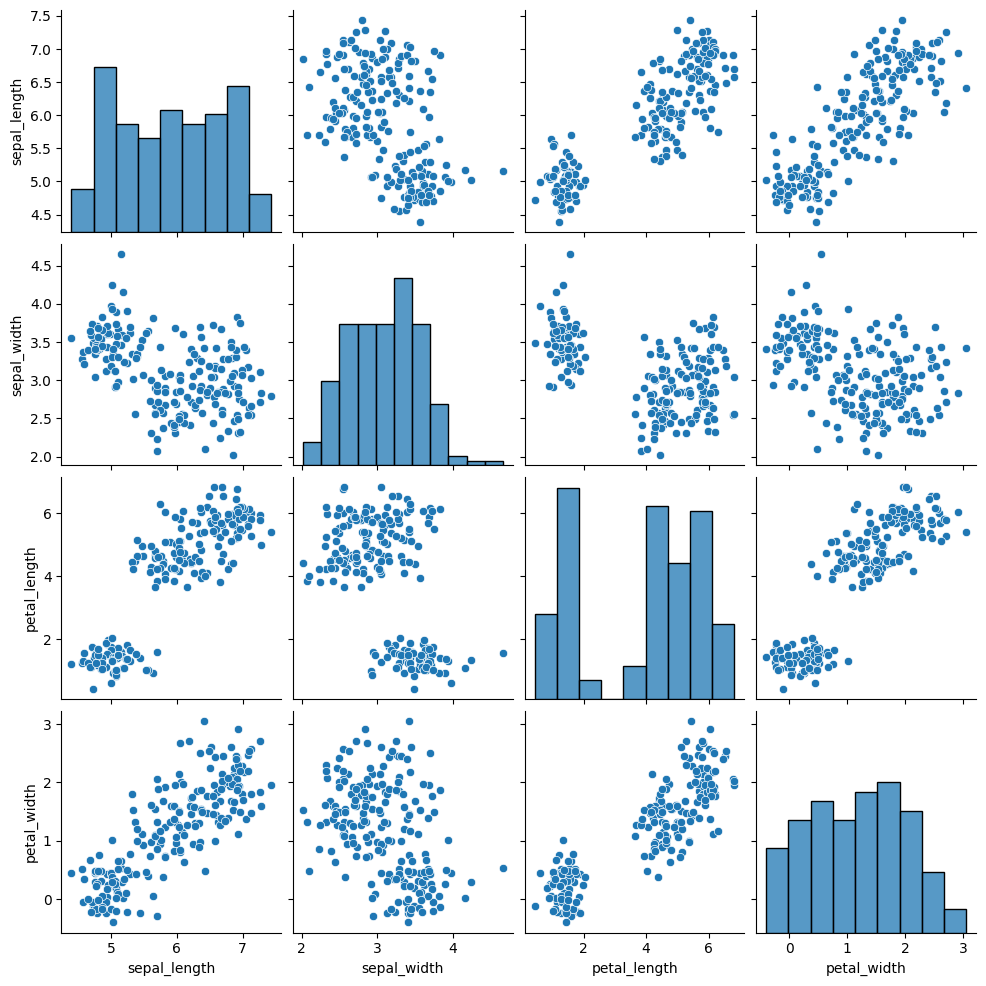

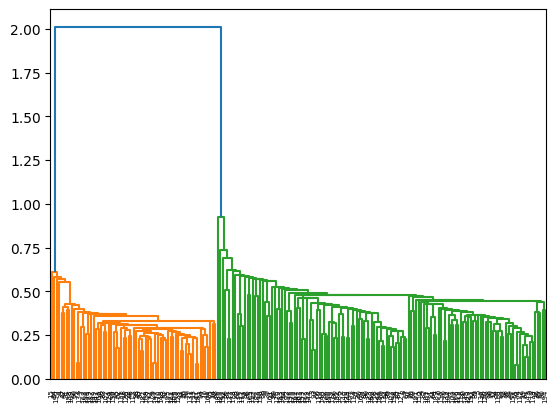

   sepal_length  sepal_width  petal_length  petal_width  predict
0      6.824299     3.502136      4.400414     1.688628        0
1      5.154514     4.655819      1.571267     0.540670        1
2      6.908632     2.489301      5.367577     2.421261        0
3      7.134277     2.548117      6.011922     2.576627        0
4      5.362229     2.560250      4.502097     1.318792        0


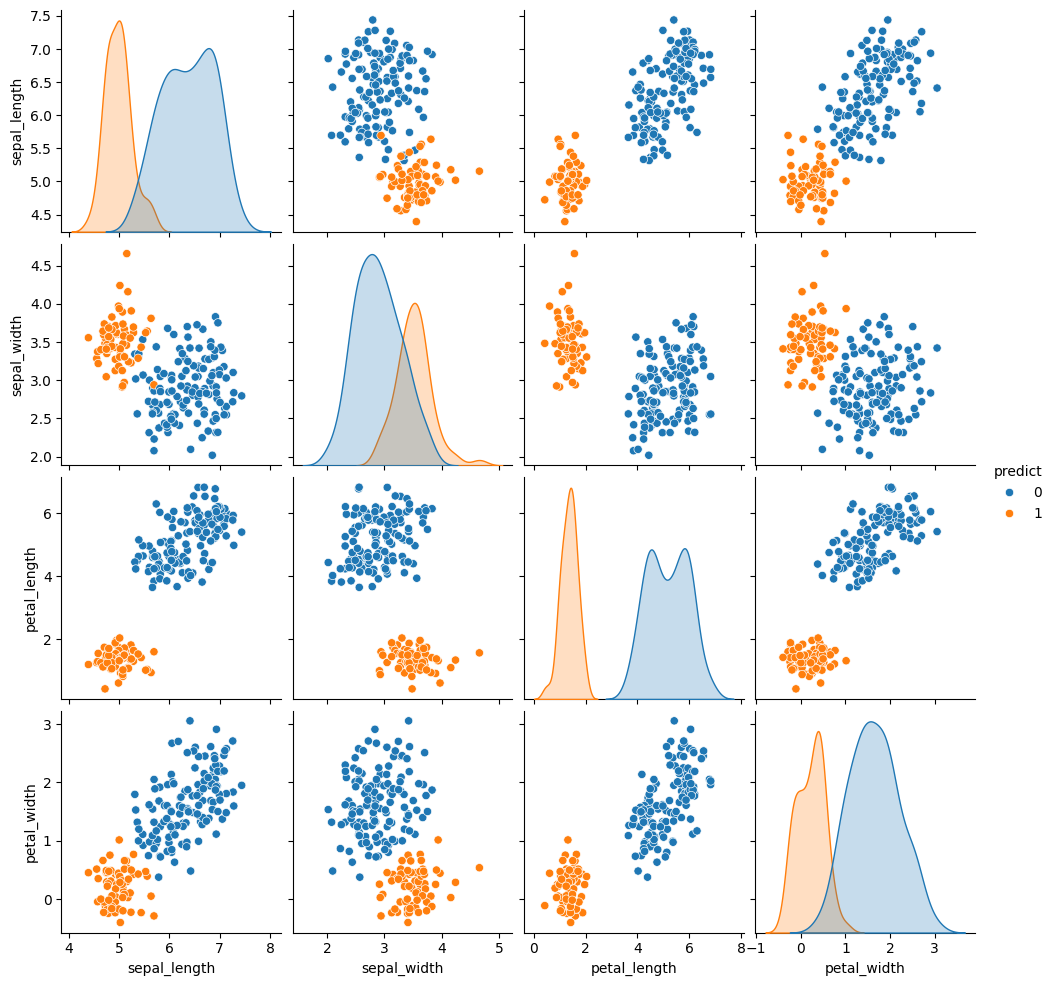

In [3]:
dataset = pd.read_csv("../datasets/iris_data.csv")
dataset.columns = dataset.columns.str.strip()
print(dataset.head())
print(dataset.isnull().sum())
sns.pairplot(data=dataset)
plt.show()
plt.Figure(figsize=(20,20))
sc.dendrogram(sc.linkage(dataset,method="single",metric='euclidean'))
plt.show()
ac = AgglomerativeClustering(n_clusters=2,linkage='single')
dataset["predict"]=ac.fit_predict(dataset)
print(dataset.head())
sns.pairplot(data=dataset,hue="predict")
plt.show()

[[ 1.38428043e+00 -4.22719150e-01]
 [ 1.34714551e+00 -5.57727532e-01]
 [-4.50558070e-01  9.28939193e-01]
 [ 7.82066581e-01 -5.45545116e-01]
 [-1.02636953e+00  3.05283299e-01]
 [ 6.28957053e-01  8.17759927e-01]
 [-8.01376335e-01  6.41705640e-01]
 [ 1.74302214e-01  4.94697287e-02]
 [ 3.18928820e-02  1.13434958e-01]
 [-1.01348150e+00  2.11467254e-01]
 [ 4.92105752e-01 -3.19713551e-01]
 [-8.67387421e-01  5.27153788e-01]
 [ 9.73653573e-01  4.71788207e-01]
 [ 2.89623184e-02  1.13368888e-01]
 [ 3.88847693e-01  9.38995040e-01]
 [ 7.50403590e-01 -5.23394150e-01]
 [ 5.93253757e-01 -4.26333505e-01]
 [ 1.53068219e+00 -3.49484254e-01]
 [ 1.23185899e-02  1.05199558e+00]
 [ 1.87870142e+00  2.37688551e-01]
 [ 1.97024807e+00  3.35246127e-01]
 [ 5.31800602e-01 -3.92360873e-01]
 [-9.80787897e-02  1.00159582e+00]
 [ 1.71929056e+00 -3.94261058e-02]
 [-7.47855819e-01  7.59774906e-01]
 [ 1.05456388e+00 -4.17614182e-01]
 [ 3.08139782e-01 -2.86070938e-01]
 [ 1.16189162e-01  3.29870884e-01]
 [ 1.17254551e+00 -5

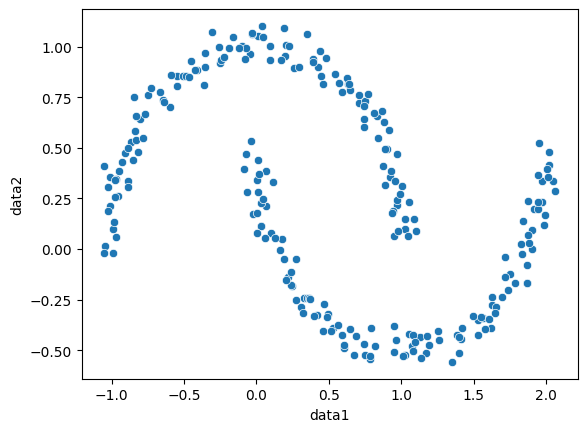

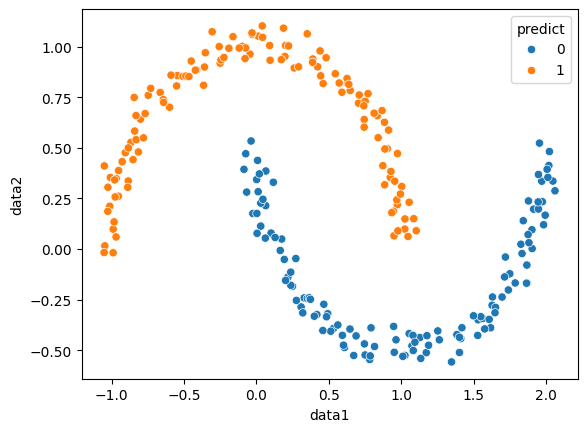

associaition learning, 5:37


In [4]:
x,y = make_moons(n_samples=250,noise=0.05)
print(x,y)
df = {"data1":x[:,0],"data2":x[:,1]}
dataset = pd.DataFrame(df)
print(dataset.head())
sns.scatterplot(x="data1",y="data2",data=dataset)
plt.show()
db = DBSCAN(eps=0.2,min_samples=5)
dataset["predict"] = db.fit_predict(dataset)
sns.scatterplot(x="data1",y="data2",data=dataset,hue="predict")
plt.show()
print("associaition learning, 5:37")

In [ ]:
pd.set_option("display.max_rows",500)
dataset = pd.read_csv("../datasets/grocery.csv")
dataset.columns = dataset.columns.str.strip()
print(dataset.head())
print(dataset.isnull().sum())
print(dataset.columns)
print(dataset.shape)
print(type(dataset["Item5"][0]))
market = []
for i in range(0,dataset.shape[0]):
    cus = []
    for j in dataset.columns:
        if type(dataset[j][i])==str:
            cus.append(dataset[j][i])
    market.append(cus)
print(market)
l = []
for i in market:
    for j in i:
        l.append(j)
p = collections.Counter(l)
p.keys()
d = {"item name": p.keys(),"values":p.values()}
print(pd.DataFrame(d).sort_values(by=["values"],ascending=False))
tr = TransactionEncoder()
tr.fit(market)
df = pd.DataFrame(tr.transform(market),columns=tr.columns_)
print(df)
apriori(df,min_support=0.05,use_colnames=True).sort_values(by=["support"])

              Item1                     Item2         Item3             Item4  \
0  abrasive cleaner          other vegetables     chocolate               NaN   
1            dishes               ready soups  cream cheese     bottled water   
2              curd                 chocolate    whole milk  other vegetables   
3             flour            tropical fruit           NaN               NaN   
4           cereals  long life bakery product        yogurt      citrus fruit   

          Item5                     Item6         Item7         Item8  
0           NaN                       NaN           NaN           NaN  
1  meat spreads  long life bakery product      UHT-milk  bottled beer  
2     pip fruit                     flour  citrus fruit           NaN  
3           NaN                       NaN           NaN           NaN  
4           NaN                       NaN           NaN           NaN  
Item1      0
Item2      0
Item3     46
Item4     88
Item5    123
Item6    167
Ite

,support,itemsets
29,0.050000,"(abrasive cleaner, butter)"
54,0.050000,"(margarine, meat spreads)"
53,0.050000,"(condensed milk, curd)"
46,0.050000,"(cereals, butter)"
42,0.050000,"(meat spreads, bottled beer)"
60,0.050000,"(potted plants, rice)"
55,0.050000,"(margarine, potted plants)"
52,0.050000,"(citrus fruit, pip fruit)"
49,0.050000,"(cereals, rice)"
47,0.050000,"(butter, rice)"


In [20]:
pd.set_option("display.max_rows",100)
dataset = pd.read_csv("../datasets/grocery.csv")
dataset.columns = dataset.columns.str.strip()
print(dataset.head())
print(dataset.isnull().sum())
print(dataset.columns)
print(dataset.shape)
print(type(dataset["Item5"][0]))
market = []
for i in range(0,dataset.shape[0]):
    cus = []
    for j in dataset.columns:
        if type(dataset[j][i])==str:
            cus.append(dataset[j][i])
    market.append(cus)
print(market)
l = []
for i in market:
    for j in i:
        l.append(j)
p = collections.Counter(l)
p.keys()
d = {"item name": p.keys(),"values":p.values()}
print(pd.DataFrame(d).sort_values(by=["values"],ascending=False))
tr = TransactionEncoder()
tr.fit(market)
df = pd.DataFrame(tr.transform(market),columns=tr.columns_)
print(df)
fpgrowth(df, min_support=0.05,use_colnames=True,max_len=3).sort_values(by=["support"])

              Item1                     Item2         Item3             Item4  \
0  abrasive cleaner          other vegetables     chocolate               NaN   
1            dishes               ready soups  cream cheese     bottled water   
2              curd                 chocolate    whole milk  other vegetables   
3             flour            tropical fruit           NaN               NaN   
4           cereals  long life bakery product        yogurt      citrus fruit   

          Item5                     Item6         Item7         Item8  
0           NaN                       NaN           NaN           NaN  
1  meat spreads  long life bakery product      UHT-milk  bottled beer  
2     pip fruit                     flour  citrus fruit           NaN  
3           NaN                       NaN           NaN           NaN  
4           NaN                       NaN           NaN           NaN  
Item1      0
Item2      0
Item3     46
Item4     88
Item5    123
Item6    167
Ite

,support,itemsets
51,0.050000,"(potted plants, abrasive cleaner)"
50,0.050000,"(potted plants, rice)"
53,0.050000,"(butter, rice)"
47,0.050000,"(cereals, rice)"
55,0.050000,"(cereals, butter)"
56,0.050000,"(abrasive cleaner, butter)"
59,0.050000,"(condensed milk, curd)"
52,0.050000,"(margarine, potted plants)"
42,0.050000,"(citrus fruit, pip fruit)"
38,0.050000,"(flour, abrasive cleaner)"


[[ 1.09689929 -0.19031554]
 [ 0.22234259 -0.55215706]
 [ 1.18259347 -0.04999956]
 ...
 [ 1.0826126  -0.83134659]
 [-0.4547455   0.37563514]
 [ 1.39482574  0.00775441]] [1 1 0 0 1 1 1 0 1 1 1 0 0 1 1 1 0 1 0 0 1 1 0 0 0 1 0 0 1 0 0 0 1 1 0 1 0
 1 0 1 1 1 0 0 1 1 0 0 1 1 0 0 1 0 0 0 1 0 1 1 1 1 1 0 0 0 0 1 0 1 0 0 1 0
 1 0 0 0 0 0 1 0 1 0 1 0 0 0 0 1 1 0 1 0 1 1 0 0 1 0 1 1 0 0 1 1 0 0 0 0 1
 1 0 0 0 1 0 0 1 0 1 1 0 0 0 0 1 1 1 1 1 0 0 1 1 0 1 1 0 0 0 1 1 1 0 0 1 0
 0 0 0 1 1 0 0 1 1 0 1 1 0 1 0 1 1 1 0 1 1 1 0 1 0 1 0 0 1 1 0 1 1 0 1 0 1
 1 1 1 0 0 0 0 0 1 0 1 0 0 1 1 1 1 1 1 0 0 1 1 0 0 0 1 0 1 1 1 0 1 0 1 1 0
 0 0 0 1 1 1 1 0 0 1 0 0 0 1 1 0 1 1 1 0 0 0 1 1 0 0 1 1 1 0 1 1 1 0 0 1 1
 1 0 0 0 1 1 0 0 0 0 0 1 1 1 0 1 1 0 0 1 0 0 0 1 1 0 1 0 1 1 1 0 1 0 0 1 1
 1 0 0 0 1 0 1 0 1 0 0 0 0 1 0 0 1 0 0 0 1 0 0 0 1 1 0 1 0 0 0 1 1 1 1 0 0
 0 1 0 0 0 1 0 1 1 1 1 1 0 0 0 1 1 1 0 1 1 0 0 0 0 0 1 1 1 1 1 0 1 0 0 1 1
 1 0 0 1 1 1 1 0 0 1 0 1 1 1 0 0 1 0 0 0 1 1 1 1 0 0 1 1 1 1 1 1 1 1 0 0 0
 0 1 1 

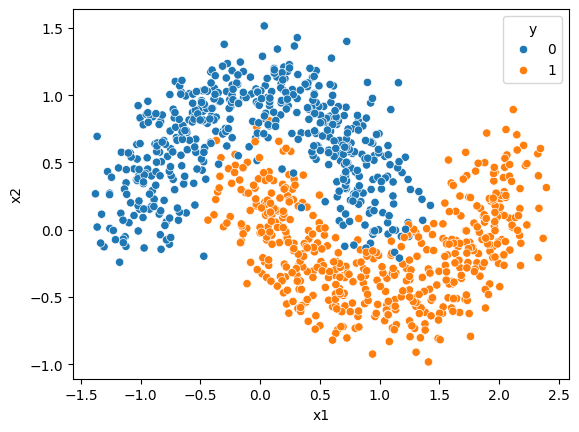

In [26]:
x,y = make_moons(n_samples=1000,noise=0.2)
print(x,y)
df = {"x1":x[:,0],"x2":x[:,1],"y":y}
dataset = pd.DataFrame(df)
print(dataset.head())
sns.scatterplot(x="x1",y="x2",data=dataset,hue="y")
plt.show()
# db = DBSCAN(eps=0.2,min_samples=5)
# dataset["predict"] = db.fit_predict(dataset)
# sns.scatterplot(x="data1",y="data2",data=dataset,hue="predict")
# plt.show()